<a href="https://colab.research.google.com/github/Tomer12-aa/student-mat.ipynb/blob/main/Titanic_Dataset_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Dataset

In [4]:
import pandas as pd
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Step 3: Understand Data

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Step 4: Data Cleaning

In [30]:
#Handle Missing Values
# Fill Age with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())



In [31]:
# Fill Embarked with most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [28]:
# Drop Cabin column (too many missing values)
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Who survived more: Male or Female?

In [11]:
survival_gender = df.groupby('Sex')['Survived'].sum()
print(survival_gender)

Sex
female    233
male      109
Name: Survived, dtype: int64


Visualization (Gender)

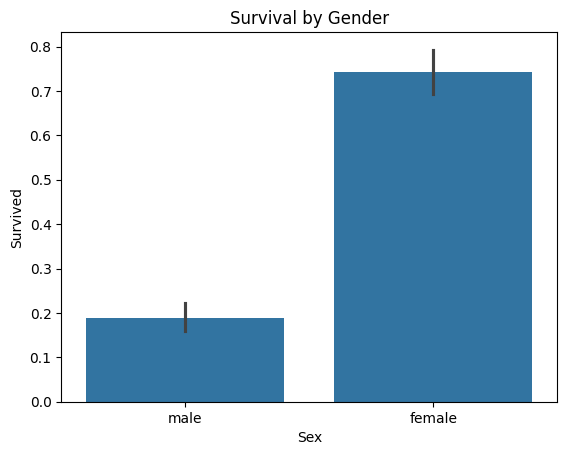

In [26]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

Did passenger class affect survival?

In [13]:
survival_class = df.groupby('Pclass')['Survived'].mean()
print(survival_class)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


Visualization (Class)

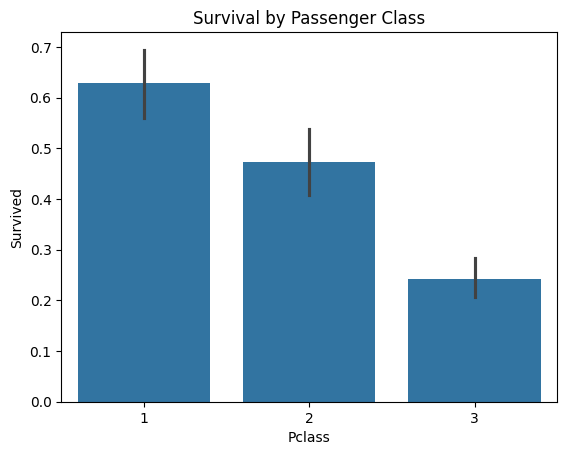

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

Survival rate by Age Group

In [21]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

Survival by Age Group

In [32]:
age_survival = df.groupby('AgeGroup', observed=False)['Survived'].mean()

Visualization (Age Group)

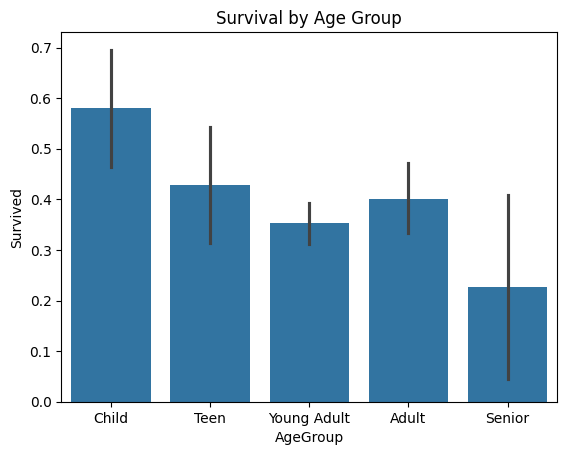

In [20]:
import seaborn as sns
sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title("Survival by Age Group")
plt.show()

Histogram of Age

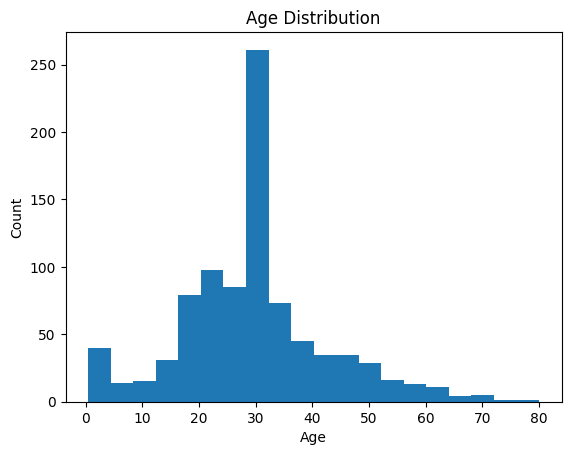

In [25]:
import matplotlib.pyplot as plt
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Conclusion
Survival depended on gender, class, and age
Data analysis helps in finding hidden patterns